In [69]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('air-traffic-passenger-statistics.csv')

### 1. EDA

In [3]:
df.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


In [4]:
df.columns

Index(['Activity Period', 'Operating Airline', 'Operating Airline IATA Code',
       'Published Airline', 'Published Airline IATA Code', 'GEO Summary',
       'GEO Region', 'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Passenger Count'],
      dtype='str')

In [5]:
df.shape

(18885, 12)

In [6]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    63
Published Airline               0
Published Airline IATA Code    63
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
dtype: int64

In [7]:
(
    df["Operating Airline IATA Code"].isnull()
    ==
    df["Published Airline IATA Code"].isnull()
).all() # The NAN cells of Operating and Published Airline IATA Codes are in the same raw.

np.True_

In [8]:
df.loc[
    df["Operating Airline IATA Code"].isnull(),
    ["Operating Airline", "Published Airline"]
].drop_duplicates()

,Operating Airline,Published Airline
148,Boeing Company,Boeing Company
6809,Servisair,Servisair
6920,Pacific Aviation,Pacific Aviation
9484,Swissport USA,Swissport USA
16868,Trego Dugan Aviation,Trego Dugan Aviation


In [9]:
df = df.dropna(
    subset=["Operating Airline IATA Code", "Published Airline IATA Code"]
)

In [10]:
df.shape

(18822, 12)

In [11]:
df["GEO Summary"].value_counts()

GEO Summary
International    11884
Domestic          6938
Name: count, dtype: int64

In [12]:
df.groupby("Operating Airline")["Passenger Count"].sum()

Operating Airline
ABC Aerolineas S.A. de C.V. dba Interjet      15585
ATA Airlines                                 384764
Aer Lingus                                   777691
Aeromexico                                  1672946
Air Berlin                                   235155
                                             ...   
WOW Air                                      295168
WestJet Airlines                             799801
World Airways                                   785
XL Airways France                            118961
Xtra Airways                                    146
Name: Passenger Count, Length: 84, dtype: int64

In [13]:
df["Activity Period"].min(), df["Activity Period"].max()

(np.int64(200507), np.int64(201806))

In [14]:
df["GEO Region"].value_counts()

GEO Region
US                     6938
Asia                   4072
Europe                 2786
Canada                 1794
Mexico                 1455
Australia / Oceania     951
Central America         381
Middle East             354
South America            91
Name: count, dtype: int64

In [15]:
df = df.drop(columns=['Terminal', 'Boarding Area'])

keys = ['Activity Period', 'Operating Airline', 'Operating Airline IATA Code',
        'Published Airline', 'Published Airline IATA Code',
        'GEO Summary', 'GEO Region', 'Activity Type Code', 'Price Category Code']

df = df.groupby(keys, as_index=False)['Passenger Count'].sum()

In [16]:
df.shape

(17217, 10)

In [17]:
iata_count = df.groupby("Operating Airline")["Operating Airline IATA Code"].nunique()

iata_count[iata_count > 1]

Operating Airline
BelAir Airlines    2
Name: Operating Airline IATA Code, dtype: int64

In [18]:
df.loc[
    df["Operating Airline"] == "BelAir Airlines",
    ["Operating Airline", "Operating Airline IATA Code"]
].drop_duplicates()

,Operating Airline,Operating Airline IATA Code
31,BelAir Airlines,4T
4084,BelAir Airlines,BBB


In [19]:
df.loc[
    df["Operating Airline"] == "BelAir Airlines",
    "Operating Airline IATA Code"
] = "4T"

In [20]:
df.groupby("Operating Airline IATA Code")

In [21]:
df.groupby("Operating Airline IATA Code").size()

Operating Airline IATA Code
4O      8
4T     22
5Y      2
9W     16
A8     22
     ... 
XJ     44
XP      2
Y4     48
YV    118
YX    116
Length: 81, dtype: int64

### 2.Feature Engineering

In [22]:
df.columns

Index(['Activity Period', 'Operating Airline', 'Operating Airline IATA Code',
       'Published Airline', 'Published Airline IATA Code', 'GEO Summary',
       'GEO Region', 'Activity Type Code', 'Price Category Code',
       'Passenger Count'],
      dtype='str')

In [23]:
df.shape

(17217, 10)

In [25]:
df.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,34090


#### 2.1. Monthly Passenger Average (Log)

In [26]:
monthly = (
    df.groupby(["Operating Airline IATA Code", "Activity Period"])["Passenger Count"]
      .sum()
      .reset_index()
)

In [27]:
monthly

,Operating Airline IATA Code,Activity Period,Passenger Count
0,4O,201803,2302
1,4O,201804,4083
2,4O,201805,3846
3,4O,201806,5354
4,4T,200507,870
...,...,...,...
6410,YX,200912,4598
6411,YX,201001,3364
6412,YX,201002,3477
6413,YX,201003,5140


In [28]:
avg_monthly = (
    monthly.groupby("Operating Airline IATA Code")["Passenger Count"]
           .mean()
           .reset_index(name="Avg Monthly Passengers")
)

In [29]:
avg_monthly.head(5)

,Operating Airline IATA Code,Avg Monthly Passengers
0,4O,3896.250000
1,4T,913.800000
2,5Y,68.000000
3,9W,8560.625000
4,A8,6.111111


In [30]:
avg_monthly["Log Avg Monthly Passengers"] = np.log1p(
    avg_monthly["Avg Monthly Passengers"]
)

In [31]:
avg_monthly["Log Avg Monthly Passengers"].head()

0    8.268026
1    6.818705
2    4.234107
3    9.055045
4    1.961659
Name: Log Avg Monthly Passengers, dtype: float64

In [35]:
n_months = monthly.groupby("Operating Airline IATA Code").size().reset_index(name="n_months")

In [36]:
n_months

,Operating Airline IATA Code,n_months
0,4O,4
1,4T,10
2,5Y,1
3,9W,8
4,A8,18
...,...,...
76,XJ,22
77,XP,1
78,Y4,24
79,YV,59


#### 2.2. Domestic Share

In [38]:
domestic_share = (
    df.groupby(["Operating Airline IATA Code", "GEO Summary"])["Passenger Count"]
      .sum()
      .unstack(fill_value=0)
)

In [39]:
domestic_share["Domestic Share"] = (
    domestic_share["Domestic"] /
    domestic_share.sum(axis=1)
)

In [41]:
domestic_share = domestic_share[["Domestic Share"]].reset_index()

In [42]:
domestic_share.shape

(81, 2)

#### 2.3. Low Fare

In [43]:
lowfare_share = (
    df.groupby(["Operating Airline IATA Code", "Price Category Code"])["Passenger Count"]
      .sum()
      .unstack(fill_value=0)
)

In [44]:
lowfare_share["Low Fare Share"] = (
    lowfare_share["Low Fare"] /
    lowfare_share.sum(axis=1)
)

In [46]:
lowfare_share = lowfare_share[["Low Fare Share"]].reset_index()

In [47]:
lowfare_share.shape

(81, 2)

#### 2.4. Transit Rate

In [48]:
transit_share = (
    df.groupby(["Operating Airline IATA Code", "Activity Type Code"])["Passenger Count"]
      .sum()
      .unstack(fill_value=0)
)

In [49]:
transit_share["Transit Share"] = (
    transit_share["Thru / Transit"] /
    transit_share.sum(axis=1)
)

In [50]:
transit_share = transit_share[["Transit Share"]].reset_index()

In [51]:
transit_share.shape

(81, 2)

#### 2.5 Region Share

In [52]:
region_share = (
    df.groupby(["Operating Airline IATA Code", "GEO Region"])["Passenger Count"]
      .sum()
      .unstack(fill_value=0)
)

In [53]:
region_share = region_share.div(region_share.sum(axis=1), axis=0)

In [54]:
region_share = region_share.drop(columns="US") #Same as Domestic Share

In [55]:
region_share.columns = [c + " Share" for c in region_share.columns] #Add Share in each column

In [56]:
region_share = region_share.reset_index()

#### 2.6. Merge

In [57]:
key = "Operating Airline IATA Code"

features = (
    avg_monthly
    .merge(n_months, on=key)
    .merge(domestic_share, on=key)
    .merge(lowfare_share, on=key)
    .merge(transit_share, on=key)
    .merge(region_share, on=key)
)

print(features.shape)

(81, 15)


In [58]:
features.head()

,Operating Airline IATA Code,Avg Monthly Passengers,Log Avg Monthly Passengers,n_months,Domestic Share,Low Fare Share,Transit Share,Asia Share,Australia / Oceania Share,Canada Share,Central America Share,Europe Share,Mexico Share,Middle East Share,South America Share
0,4O,3896.250000,8.268026,4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,4T,913.800000,6.818705,10,0.0,0.0,0.030422,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,5Y,68.000000,4.234107,1,1.0,0.0,0.044118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9W,8560.625000,9.055045,8,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A8,6.111111,1.961659,18,1.0,0.0,0.072727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
features = features[features["n_months"] >= 12]
print(features.shape)

(65, 15)


### 3. Clustering

In [60]:
X = features.drop(columns=["Operating Airline IATA Code",
                           "Avg Monthly Passengers",
                           "n_months"])

In [61]:
X_scaled = StandardScaler().fit_transform(X)

In [70]:
wcss = []
ss = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    wcss.append(model.inertia_)
    ss1=silhouette_score(X_scaled, labels)
    ss.append(ss1)
    print(ss1)
    

0.21804076932685412
0.2809723721230202
0.36469192713044074
0.43489644294887714
0.46686102792645
0.5291873270052181
0.5682605484287828
0.6406109295672925
0.6667938688712709


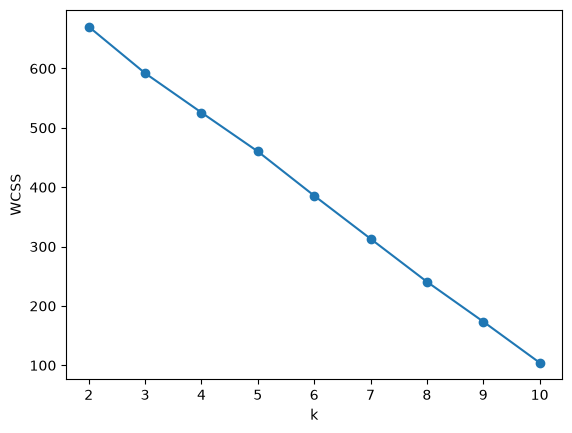

In [71]:
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

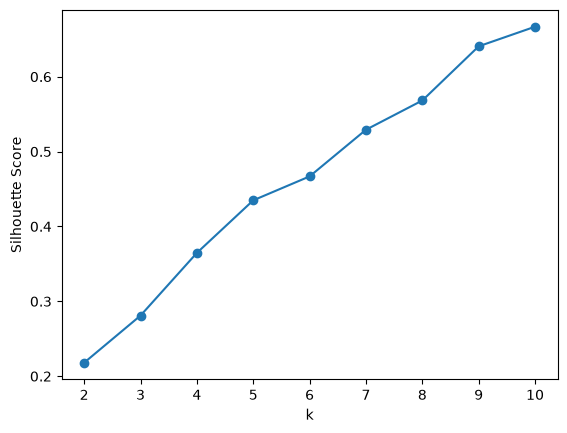

In [72]:
plt.plot(range(2, 11), ss, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

In [73]:
region_share.columns

Index(['Operating Airline IATA Code', 'Asia Share',
       'Australia / Oceania Share', 'Canada Share', 'Central America Share',
       'Europe Share', 'Mexico Share', 'Middle East Share',
       'South America Share'],
      dtype='str')

In [74]:
features["Long Haul Share"] = features[["Asia Share", "Europe Share",
                                        "Australia / Oceania Share",
                                        "Middle East Share"]].sum(axis=1)
X = features[["Log Avg Monthly Passengers", "Domestic Share",
              "Low Fare Share", "Transit Share", "Long Haul Share"]]

X_scaled = StandardScaler().fit_transform(X)
print(X.shape)

(65, 5)


In [75]:
wcss = []
ss = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    wcss.append(model.inertia_)
    ss1=silhouette_score(X_scaled, labels)
    ss.append(ss1)
    print(ss1)

0.4949637253466818
0.5265876236898859
0.5944159556272854
0.6174803522974079
0.7009060598271382
0.6985478070410747
0.702788685797792
0.6928365660594312
0.7022946275633295


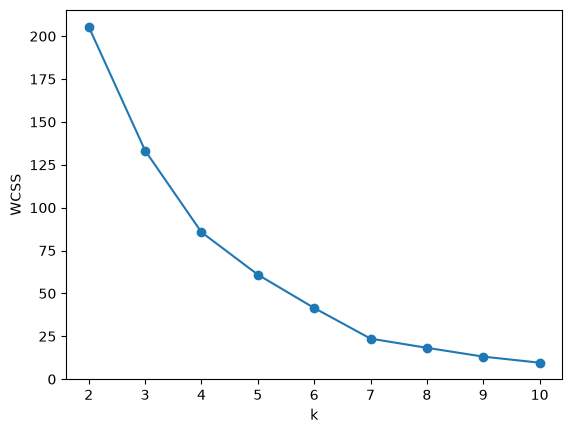

In [76]:
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

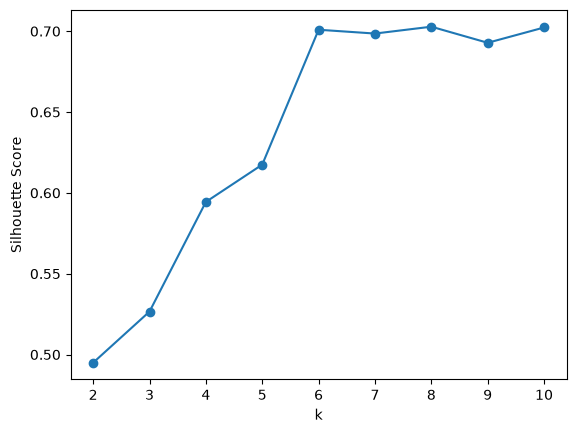

In [77]:
plt.plot(range(2, 11), ss, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

In [78]:
final_model = KMeans(n_clusters=6, random_state=42, n_init=10)
features["Cluster"] = final_model.fit_predict(X_scaled)

In [79]:
print(silhouette_score(X_scaled, features["Cluster"]))

0.7009060598271382


In [80]:
features["Cluster"].value_counts().sort_index()

Cluster
0     9
1    30
2     8
3     8
4     8
5     2
Name: count, dtype: int64

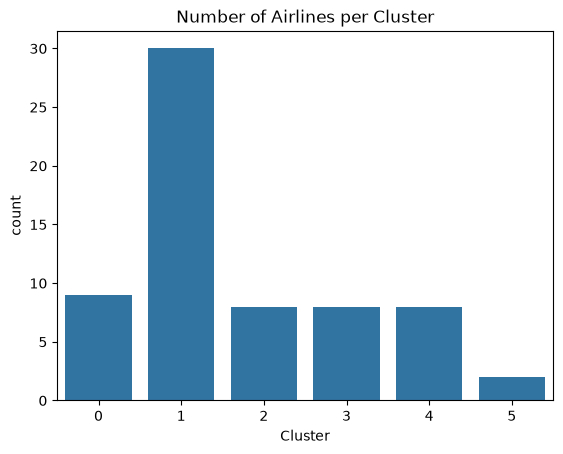

In [83]:
sns.countplot(x=features["Cluster"])
plt.title("Number of Airlines per Cluster")
plt.show()

In [84]:
cluster_profile = features.groupby("Cluster")[[
    "Log Avg Monthly Passengers",
    "Domestic Share",
    "Low Fare Share",
    "Transit Share",
    "Long Haul Share"
]].mean()

cluster_profile.round(3)

,Log Avg Monthly Passengers,Domestic Share,Low Fare Share,Transit Share,Long Haul Share
Cluster,,,,,
0,8.583,0.998,0.000,0.000,0.000
1,9.616,0.000,0.003,0.000,1.000
2,10.471,0.871,1.000,0.000,0.000
3,9.423,0.000,0.000,0.000,0.000
4,12.208,0.931,0.019,0.003,0.035
5,5.939,0.999,0.500,0.089,0.000


In [85]:
features[[
    "Operating Airline IATA Code",
    "Cluster"
]].sort_values("Cluster")

,Operating Airline IATA Code,Cluster
35,GL,0
36,HA,0
76,XJ,0
75,XE,0
79,YV,0
...,...,...
68,US,4
67,UA,4
11,AS,4
4,A8,5


In [86]:
for c in sorted(features["Cluster"].unique()):
    airlines = features.loc[
        features["Cluster"] == c,
        "Operating Airline IATA Code"
    ].tolist()
    
    print(f"Cluster {c} ({len(airlines)} airlines):")
    print(airlines)
    print()

Cluster 0 (9 airlines):
['GL', 'HA', 'MQ', 'QX', 'RW', 'XE', 'XJ', 'YV', 'YX']

Cluster 1 (30 airlines):
['AB', 'AF', 'AI', 'BA', 'BR', 'CA', 'CI', 'CX', 'CZ', 'EI', 'EK', 'EY', 'FJ', 'JL', 'KE', 'KL', 'LH', 'LX', 'MU', 'NH', 'NZ', 'OZ', 'PR', 'QF', 'SE', 'SK', 'SQ', 'TK', 'VS', 'WW']

Cluster 2 (8 airlines):
['B6', 'F9', 'FL', 'NK', 'SY', 'VX', 'WN', 'Y4']

Cluster 3 (8 airlines):
['AC', 'AM', 'CM', 'LP', 'MX', 'QK', 'TA', 'WS']

Cluster 4 (8 airlines):
['AA', 'AS', 'CP', 'DL', 'NW', 'OO', 'UA', 'US']

Cluster 5 (2 airlines):
['A8', 'TZ']



### 4. Conclusion

In [90]:
cluster_names = {
    0: "Smaller Domestic Carriers",
    1: "Long-Haul International Carriers",
    2: "Domestic Low-Fare Carriers",
    3: "Non-Long-Haul International Carriers",
    4: "Large Domestic / Network Carriers",
    5: "Small Specialized Domestic Carriers"
}

features["Traffic Profile"] = features["Cluster"].map(cluster_names)

In [91]:
airline_profiles = features[[
    "Operating Airline IATA Code",
    "Cluster",
    "Traffic Profile",
    "Log Avg Monthly Passengers",
    "Domestic Share",
    "Low Fare Share",
    "Transit Share",
    "Long Haul Share"
]].sort_values(["Cluster", "Operating Airline IATA Code"])

airline_profiles

,Operating Airline IATA Code,Cluster,Traffic Profile,Log Avg Monthly Passengers,Domestic Share,Low Fare Share,Transit Share,Long Haul Share
35,GL,0,Smaller Domestic Carriers,4.970970,0.983702,0.000000,0.000000,0.000000
36,HA,0,Smaller Domestic Carriers,9.861784,1.000000,0.000000,0.000000,0.000000
45,MQ,0,Smaller Domestic Carriers,8.988952,1.000000,0.000000,0.000000,0.000000
58,QX,0,Smaller Domestic Carriers,9.306180,1.000000,0.000000,0.000000,0.000000
59,RW,0,Smaller Domestic Carriers,8.275122,1.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
53,OO,4,Large Domestic / Network Carriers,12.562996,0.933742,0.000026,0.000005,0.000000
67,UA,4,Large Domestic / Network Carriers,14.150170,0.805000,0.020204,0.004911,0.152737
68,US,4,Large Domestic / Network Carriers,11.817604,1.000000,0.120093,0.000000,0.000000
4,A8,5,Small Specialized Domestic Carriers,1.961659,1.000000,0.000000,0.072727,0.000000


In [94]:
airline_profiles[airline_profiles["Cluster"] == 5]

,Operating Airline IATA Code,Cluster,Traffic Profile,Log Avg Monthly Passengers,Domestic Share,Low Fare Share,Transit Share,Long Haul Share
4,A8,5,Small Specialized Domestic Carriers,1.961659,1.000000,0.0,0.072727,0.0
66,TZ,5,Small Specialized Domestic Carriers,9.915996,0.997424,1.0,0.104867,0.0


In [95]:
cluster_names = {
    0: "Smaller Domestic Carriers",
    1: "Long-Haul International Carriers",
    2: "Domestic Low-Fare Carriers",
    3: "Non-Long-Haul International Carriers",
    4: "Large Domestic / Network Carriers",
    5: "Domestic Carriers with Transit Activity"
}

features["Traffic Profile"] = features["Cluster"].map(cluster_names)